In [ ]:
#--------------1------------
import pandas as pd
from sklearn.datasets import fetch_openml

# Load dataset from OpenML
boston = fetch_openml(name="boston", version=1, as_frame=True)

df = boston.frame

# Rename target column to MEDV (as per your PDF format)
df.rename(columns={'target': 'MEDV'}, inplace=True)

# Save as CSV
df.to_csv("boston.csv", index=False)

print("boston.csv file created successfully!")
df.head()

boston.csv file created successfully!


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
#--------------2------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('boston.csv')   # upload your dataset in Colab

print("First 5 rows:")
display(df.head())

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
#--------------3---------------
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
#--------------4-------------
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


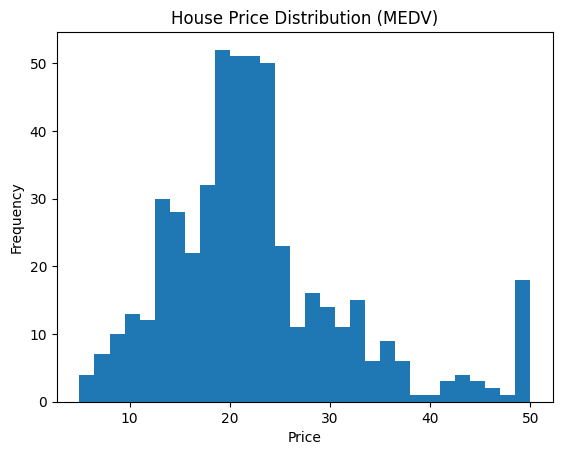

In [ ]:
#--------------5-----------------
plt.figure()
plt.hist(df['MEDV'], bins=30)
plt.title("House Price Distribution (MEDV)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

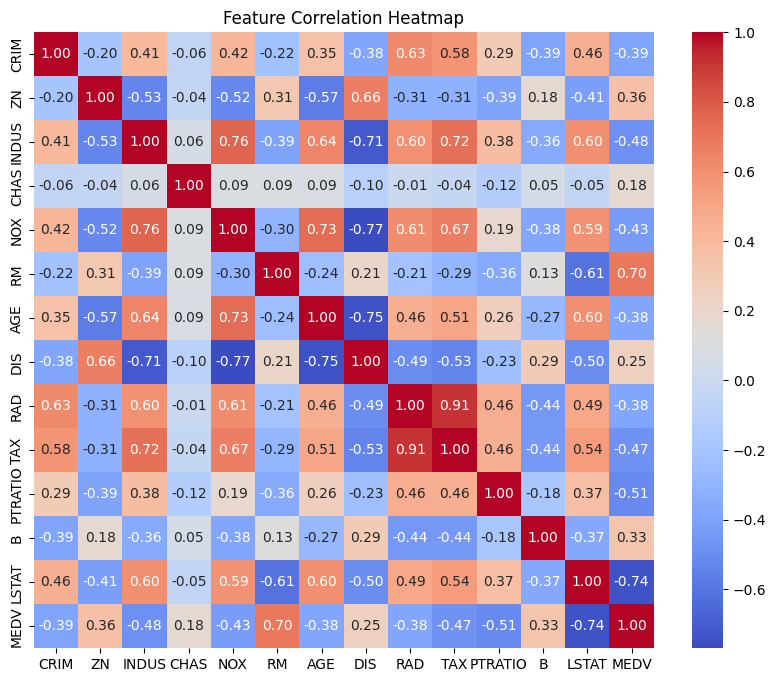

In [ ]:
#--------------6-----------------
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

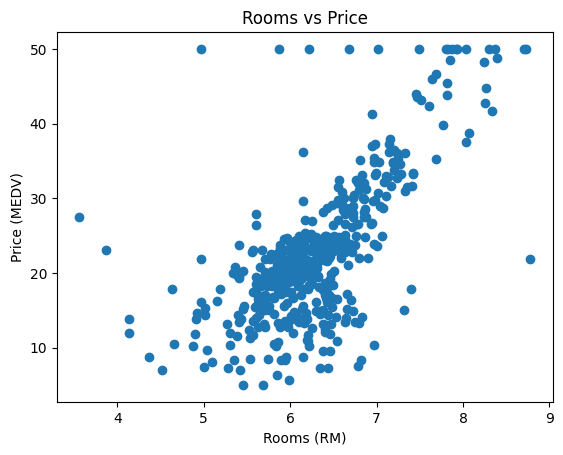

In [ ]:
#--------------7--------------
# RM vs MEDV
plt.figure()
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel("Rooms (RM)")
plt.ylabel("Price (MEDV)")
plt.title("Rooms vs Price")
plt.show()


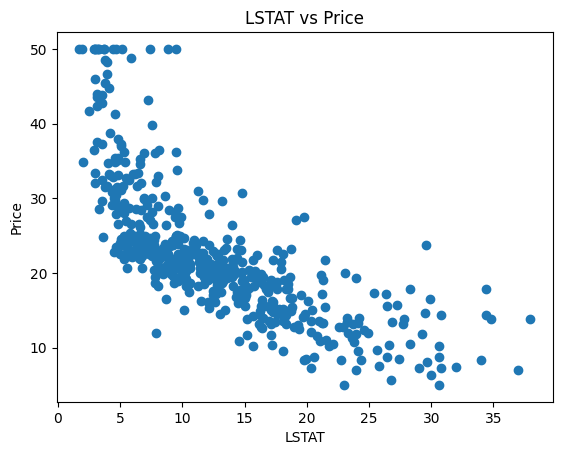

In [ ]:
#--------------8------------------
# LSTAT vs MEDV
plt.figure()
plt.scatter(df['LSTAT'], df['MEDV'])
plt.xlabel("LSTAT")
plt.ylabel("Price")
plt.title("LSTAT vs Price")
plt.show()

In [ ]:
#--------------9----------------
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")
print("Intercept:", model.intercept_)



Training samples: (404, 13)
Testing samples: (102, 13)
Model trained successfully
Intercept: 30.24675099392366


In [ ]:
#--------------10---------------
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(comparison.head())

,Actual,Predicted
0,23.6,28.996724
1,32.4,36.025565
2,13.6,14.816944
3,22.8,25.031979
4,16.1,18.769880


In [ ]:
#--------------11-----------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.189091965887837
MSE: 24.291119474973478
RMSE: 4.928602182665332
R2 Score: 0.6687594935356326


In [ ]:
#--------------12---------------
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)
display(coefficients)

,Feature,Coefficient
5,RM,4.438835
3,CHAS,2.784438
8,RAD,0.262430
2,INDUS,0.040381
1,ZN,0.030110
11,B,0.012351
6,AGE,-0.006296
9,TAX,-0.010647
0,CRIM,-0.113056
12,LSTAT,-0.508571


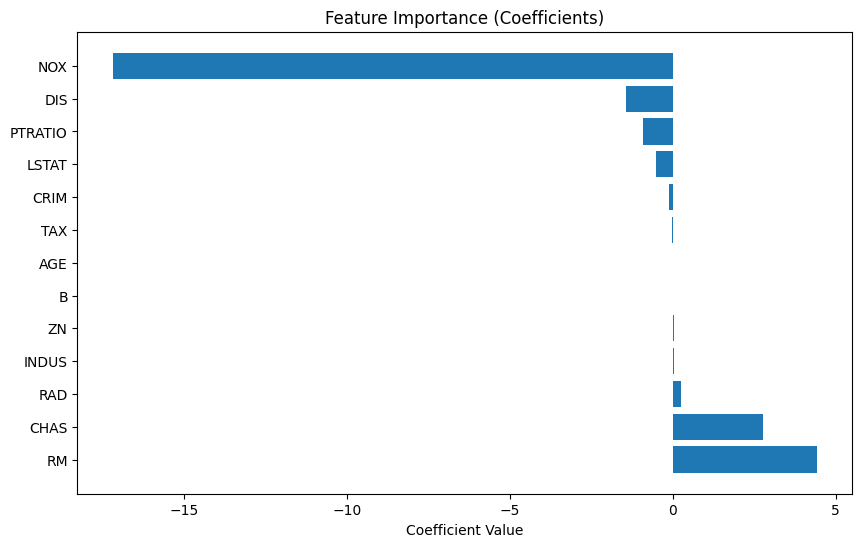

In [ ]:
#--------------13----------------
plt.figure(figsize=(10,6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'])
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()

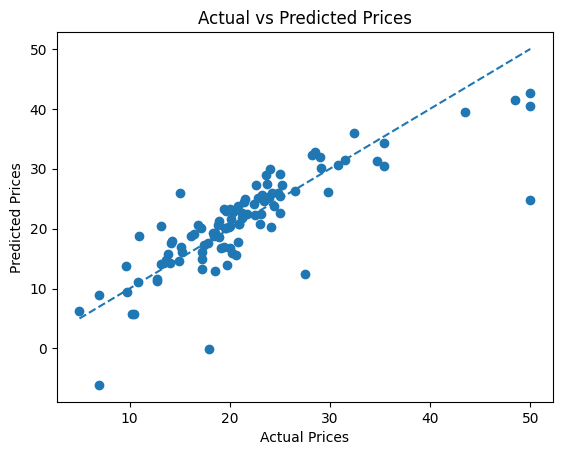

In [ ]:
#--------------14-----------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

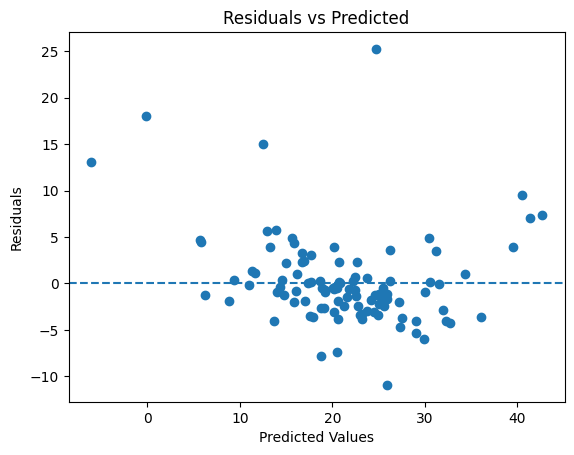

In [ ]:
#--------------15------------------
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

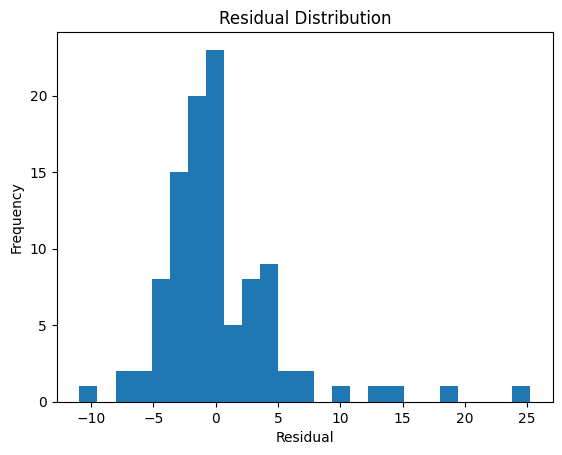

In [ ]:
#--------------16-----------------
plt.figure()
plt.hist(residuals, bins=25)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

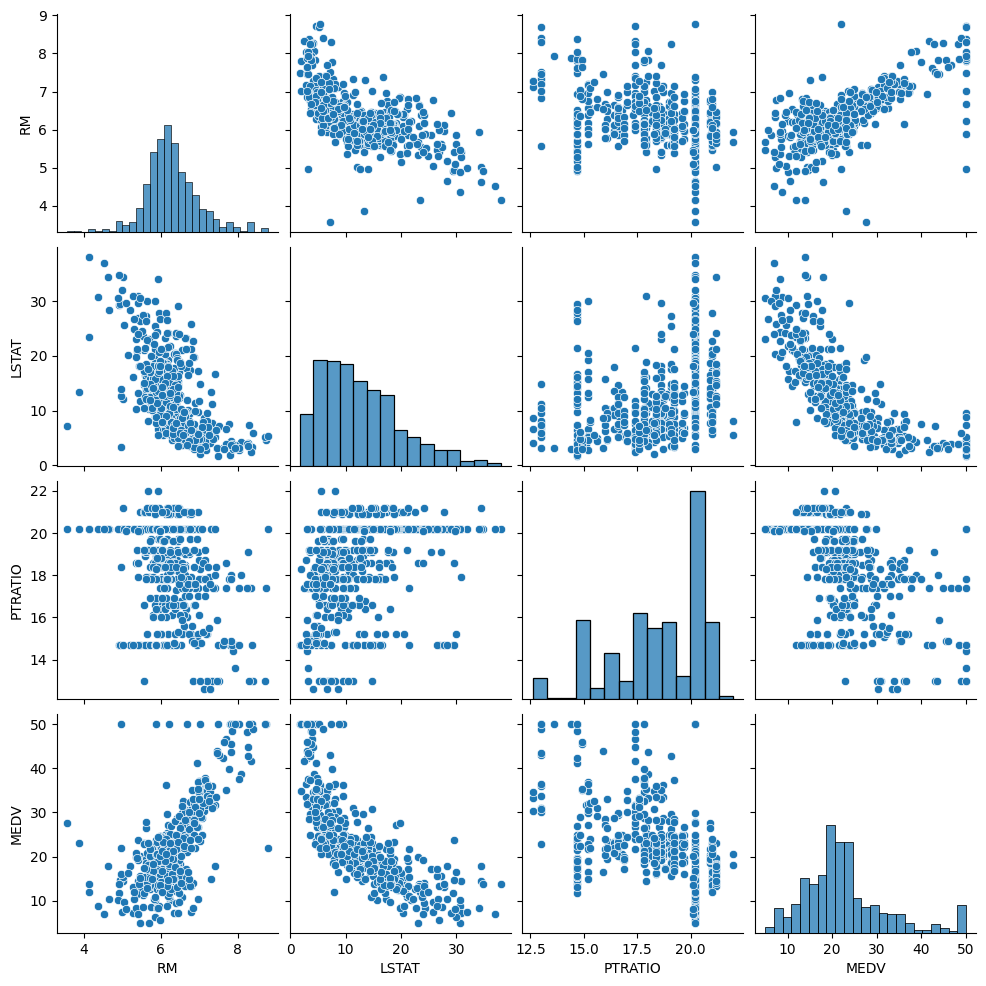

In [ ]:
#--------------17-------------
sns.pairplot(df[['RM','LSTAT','PTRATIO','MEDV']])
plt.show()